# 反爬：驗證碼處理

* 了解「驗證碼機制」的反爬蟲機制
* 「驗證碼機制」反爬蟲的因應策略


## 作業目標

* 讀取黑白驗證碼圖檔：讀取作業附件中的圖片 (`test1.png`, `test2.png`)
* 讀取背景更複雜的圖檔：像 test/test2.png 這種複雜的圖片怎麼辦？


In [2]:
!pip install pytesseract

### 讀取黑白驗證碼圖檔
- 請讀取作業附件中的圖片 (`test1.png`, `test2.png`)

In [11]:
from PIL import Image
import pytesseract

# 如果你是 Windows 用戶，這一行是必要的（如果 pytesseract 無法自動找到 tesseract.exe）
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

# 直接開啟本機圖片（不用 requests）
image_path = r"C:\Users\a7890\Desktop\Lerning\Python Scraping\Day50_HW\test1.png"
image = Image.open(image_path)

# 執行 OCR
text = pytesseract.image_to_string(image)
print("辨識文字：", text)


辨識文字： 619121



### 像 test/test2.png 這種複雜的圖片怎麼辦？

- 讀取看是否成功轉出正確的數字


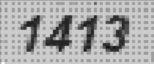

In [20]:
image_path = r"C:\Users\a7890\Desktop\Lerning\Python Scraping\Day50_HW\test2.png"
img = Image.open(image_path).convert("L")  # 圖片風格轉換
img

In [21]:
text = pytesseract.image_to_string(img)
print("辨識文字：", text)

辨識文字： 4413



> 無法讀取出正確的數字，需要對圖片進行處理，將背景去除變成黑白圖片

- 利用以下函式對圖片進行處理

In [22]:
def binarizing(img, threshold): #input: gray image
    pixdata = img.load()
    w, h = img.size
    for y in range(h):
        for x in range(w):
            if pixdata[x, y] < threshold:
                pixdata[x, y] = 0
            else:
                pixdata[x, y] = 255
    return img


def depoint(img):   #input: gray image
    pixdata = img.load()
    w,h = img.size
    for y in range(1,h-1):
        for x in range(1,w-1):
            count = 0
            if pixdata[x,y-1] > 245:
                count = count + 1
            if pixdata[x,y+1] > 245:
                count = count + 1
            if pixdata[x-1,y] > 245:
                count = count + 1
            if pixdata[x+1,y] > 245:
                count = count + 1
            if count > 2:
                pixdata[x,y] = 255
    return img


In [23]:
text = pytesseract.image_to_string(img)
print("辨識文字：", text)

辨識文字： 4413



In [24]:
# 放大圖片
img = img.resize((img.width * 2, img.height * 2), Image.LANCZOS)

# 再轉成黑白
bw = img.point(lambda x: 0 if x < 145 else 255, '1')
text = pytesseract.image_to_string(bw, config='--psm 6 -c tessedit_char_whitelist=0123456789')
print("放大後辨識：", text)


放大後辨識： 4413



In [25]:
text = pytesseract.image_to_string(bw, config='--psm 6 -c tessedit_char_whitelist=0123456789')

